<table>
<tr>
<td><table><tr><td><h1>Procesamiento de Imágenes: Clasificación de Ruido y Denoising</h1></td></tr>
           <tr><td><h3>Classical Convolutional Neural Network for mixed noise classification and denoissing images with a Convolutional Variational Autoencoder</h3></td></tr></table></td>
</tr>
</table>

**Objetivos**. \11. **Clasificación de imágenes con ruido mixto**: Diseñar y entrenar una Red Neuronal Convolucional (CNN) capaz de identificar qué combinación de distorsiones (Gaussiano, Sal y Pimienta, o Speckle) ha sido aplicada a una imagen.
2. **Denoising mediante Autoencoder Variacional Convolucional (ConvVAE)**: Implementar un modelo generativo capaz de reconstruir imágenes limpias a partir de versiones degradadas mediante aprendizaje de representaciones latentes continuas.
3. **Optimización de funciones de pérdida complejas**: Analizar el equilibrio entre fidelidad de reconstrucción y regularización latente mediante la divergencia KL y el hiperparámetro $\beta$ en arquitecturas $\beta$-VAE.
4. **Explicabilidad de modelos de clasificación (XAI para CNN)**: Aplicar técnicas de interpretabilidad visual y basada en gradientes para comprender. \1    - qué patrones utiliza la CNN para clasificar ruido,
    - cómo organiza su espacio latente,
    - y qué regiones de la imagen dominan la decisión.
5. **Explicabilidad del ConvVAE para denoising**: Estudiar el comportamiento interno del encoder, decoder y espacio latente del ConvVAE mediante. \1    - análisis geométrico del embedding,
    - mapas de saliencia,
    - errores residuales,
    - y traversals latentes.
6. **Preparación para comparación clásica vs híbrida cuántica**: Construir una baseline clásica interpretable que permita comparar posteriormente modelos híbridos cuánticos (CQNN y VQAE) tanto en rendimiento como en interpretabilidad.

**Índice**. \1
1. **Introducción y preprocesamiento de datos**

    1.1. Planteamiento del problema

    1.2. Modelización del ruido

    1.3. Construcción de datasets

2. **Clasificación de ruido con CNN**

    2.1. Arquitectura de la red e integración latente

    2.2. Bucle de entrenamiento y evaluación

    2.3. Matriz de confusión e interpretación

3. **Eliminación de ruido mediante Autoencoder Variacional (ConvVAE)**

    3.1. Estructura del encoder y decoder

    3.2. Truco de la reparametrización

    3.3. Función de pérdida VAE con regularización de $\beta$

4. **Resultados y evaluación cuantitativa**

    4.1. Reconstrucciones y análisis visual

    4.2. Métricas de evaluación

   - MSE
   - PSNR
   - SSIM

    4.3. Discusión de resultados

5. **Explicabilidad de la CNN de clasificación de ruido**

    5.1. Visualización de activaciones internas

    5.2. Saliency Maps

    5.3. Integrated Gradients

    5.4. Grad-CAM

    5.5. Occlusion Sensitivity

    5.6. Visualización del espacio latente de 4 dimensiones

    5.7. Análisis de errores

    5.8. LIME para explicación local de clasificación de ruido

    5.9. SHAP / DeepLIFT para atribución de píxeles

    5.10. Comparativa global de métodos XAI aplicados a la CNN clásica

6. **Explicabilidad del ConvVAE para denoising de imágenes**

    6.1. Visualización de reconstrucciones y análisis cualitativo

    6.2. Organización del espacio latente con PCA

    6.3. t-SNE del espacio latente

    6.4. Saliency del ConvVAE

    6.5. Error residual y pérdida de información

    6.6. Traversals latentes del decoder

    6.7. Conclusiones XAI del ConvVAE

7. **Conclusiones generales y trabajo futuro**

    7.1. Conclusiones sobre clasificación de ruido

    7.2. Conclusiones sobre denoising

    7.3. Limitaciones del estudio

    7.4. Futuro trabajo: modelos híbridos cuánticos (CQNN y VQAE)

## 1. Introducción y preprocesamiento de datos

### 1.1. Planteamiento del problema

El objetivo de este notebook es doble. En primer lugar, se trabaja con un problema de clasificación supervisada donde la red debe adivinar la naturaleza del ruido aplicado a una imagen del dataset MNIST. En segundo lugar, se aborda un problema de aprendizaje autosupervisionado enfocado en la restauración de imágenes mediante una red generativa de reducción de dimensionalidad (ConvVAE).

- **Se utilizan para train, validation y test sets muestras pequeñas de datos. Pues el objetivo del problema es comparar la versión clásica vs la híbrida cuántica. La versión híbrida cuántica requiere pocos datos de muestra por la complejidad computacional que requiere en local ejecutar circuitos cuánticos (simuladores).**

- training dataset: 400 muestras (subdividido en 300 para entrenamiento y 100 para validación).

- test dataset: 100 muestras.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import cat
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
)
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from common_utils import plot_training_curves, plot_confusion_matrix, evaluate_model, mostrar_reconstrucciones

In [2]:
transform = transforms.Compose([transforms.ToTensor()])


X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [3]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [4]:
train_size = 300
val_size = 100

train_subset, val_subset = random_split(X_train, [train_size, val_size])

### 1.2. Modelización del ruido

Para simular entornos de baja calidad de captura o transmisión, se definen tres funciones de degradación estocástica sobre la imagen original \(x\). \1
#### Ruido Gaussiano
Añade ruido blanco aditivo con una desviación estándar ($\sigma$ = 0.25), acotando el resultado en el rango válido \([0, 1]\). \1
$$
x_{\text{gaussian}} = \max\left(0, \min\left(1, x + \mathcal{N}(0, \sigma^2)\right)\right)
$$

#### Ruido de Sal y Pimienta (Impulsivo)
Modifica una fracción probabilística de los píxeles de la imagen (ajustada en $ \text{prob} = 0.15 $), asignándoles de forma equiprobable el valor mínimo $0$ (pimienta) o el valor máximo $1$ (sal).

#### Ruido Speckle (Multiplicativo)
Común en imágenes de radar, el ruido es proporcional a la intensidad del propio píxel, usando \(\sigma = 0.35\). \1
$$
x_{\text{speckle}} = \max\left(0, \min\left(1, x + x \cdot \mathcal{N}(0, \sigma^2)\right)\right)
$$

Las imágenes de entrenamiento se generan aplicando combinaciones mixtas de estos ruidos de manera aleatoria mediante la función `apply_mixed_noise(img)`, la cual define nuestras tres clases de destino (targets). \1
| Clase | Combinación de Ruido Aplicada |
|-------|-------------------------------|
| 0     | Ruido Gaussiano + Ruido Speckle |
| 1     | Ruido Gaussiano + Ruido Sal y Pimienta |
| 2     | Ruido Sal y Pimienta + Ruido Speckle |

In [5]:
def gaussian_noise(img, sigma=0.25): # antes 0.1
    noise = torch.randn_like(img) * sigma
    return torch.clamp(img + noise, 0, 1)

def salt_pepper(img, prob=0.15): # antes 0.05
    noisy = img.clone()

    mask = torch.rand_like(img)

    noisy[mask < prob/2] = 0
    noisy[mask > 1 - prob/2] = 1

    return noisy

def speckle(img, sigma=0.35): # antes 0.2
    noise = torch.randn_like(img) * sigma
    return torch.clamp(img + img * noise, 0, 1)


def apply_mixed_noise(img):
    r = np.random.randint(3)

    # gaussian + speckle
    if r == 0:
        img = gaussian_noise(img)
        img = speckle(img)
        label = 0

    # gaussian + salt & pepper
    elif r == 1:
        img = gaussian_noise(img)
        img = salt_pepper(img)
        label = 1

    # salt & pepper + speckle
    else:
        img = salt_pepper(img)
        img = speckle(img)
        label = 2

    return img, label


In [6]:
class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset

        # Aquí preprocesamos todas las imágenes y guardamos el ruido y las etiquetas
        self.noisy_images = []
        self.labels = []

        for img, _ in self.mnist:
            noisy_img, label = apply_mixed_noise(img)
            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        # Comprobación de consistencia
        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")


    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]


train_dataset = NoisyMNISTDataset(train_subset)
val_dataset = NoisyMNISTDataset(val_subset)
test_dataset = NoisyMNISTDataset(X_test)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))

print(images.shape)  # [32, 1, 28, 28]
print(labels.shape)


torch.Size([32, 1, 28, 28])
torch.Size([32])


## 2. Clasificación de ruido con CNN

### Arquitectura de la red
La red encargada de clasificar el tipo de ruido procesa tensores de entrada con dimensiones $[B, 1, 28, 28]$, donde $B$ es el tamaño del batch. La arquitectura combina un extractor de características convolucional con un bloque fully connected.

#### Extractor Convolucional

- **Capa conv1:** `Conv2d(1 → 16 filtros, kernel=5×5, padding=2)`. Mantiene la dimensión espacial $(28×28)$. Activación ReLU.
- **Capa pool:** `MaxPool2d(kernel=2×2, stride=2)`. Reduce el espacio a la mitad $(14×14)$.
- **Capa conv2:** `Conv2d(16 → 32 filtros, kernel=5×5, padding=2)`. Mantiene dimensión $(14×14)$. Activación ReLU.
- **Capa pool:** Reduce el espacio final a un mapa de características de $7×7$.

#### Bloque de Clasificación e Interfaz Cuántica

- El mapa de características se aplana (flatten) a un vector de tamaño $32 × 7 × 7 = 1568$.
- Tras pasar por una capa lineal intermedia (fc1) de 128 neuronas con activación ReLU, el flujo entra en la capa fc2 que reduce la dimensión a 4 y aplica una función tangente hiperbólica escalada por $\pi$. \1
$$
\eta = \tanh(\text{fc2}(x)) \cdot \pi
$$

> **Nota de Arquitectura:** Esta restricción de rango a $[-\pi, \pi]$ en un espacio de 4 dimensiones está diseñada específicamente para actuar como un codificador de ángulos de fase (Angle Embedding), emulando la interfaz de entrada para un circuito cuántico (QNN).

- Finalmente, el bloque `feature_mixer` (un perceptrón multicapa secuencial con activaciones Tanh) procesa este espacio latente para mapearlo a las 3 clases finales (tipos de ruido mezclados).

In [8]:
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,16,5,padding=2)
        self.conv2 = nn.Conv2d(16,32,5,padding=2)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*7*7,128)
        self.fc2 = nn.Linear(128,4)

        # equivalente al espacio cuántico
        self.feature_mixer = nn.Sequential(
            nn.Linear(4,16),
            nn.Tanh(),

            nn.Linear(16,16),
            nn.Tanh(),

            nn.Linear(16,3)
        )

    def forward(self,x):

        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # LIME genera tensores que no siempre son contiguos en memoria, y .view() solo funciona con tensores contiguos.
        # x = x.view(x.size(0),-1)
        # Por ello, utilizamos .reshape() que funciona con tensores no contiguos.
        x = x.reshape(x.size(0), -1)

        x = F.relu(self.fc1(x))

        x = torch.tanh(self.fc2(x)) * np.pi

        x = self.feature_mixer(x)

        return x

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClassicalNet().to(device)

In [10]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 10

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.0735 | Train Acc: 0.3800 | Val Loss: 1.0459 | Val Acc: 0.3200
Epoch 2/10 | Train Loss: 0.9338 | Train Acc: 0.5633 | Val Loss: 0.8657 | Val Acc: 0.6700
Epoch 3/10 | Train Loss: 0.7759 | Train Acc: 0.7000 | Val Loss: 0.8082 | Val Acc: 0.5100
Epoch 4/10 | Train Loss: 0.6412 | Train Acc: 0.7700 | Val Loss: 0.6798 | Val Acc: 0.6600
Epoch 5/10 | Train Loss: 0.5585 | Train Acc: 0.8367 | Val Loss: 0.5172 | Val Acc: 0.9600
Epoch 6/10 | Train Loss: 0.4152 | Train Acc: 0.9867 | Val Loss: 0.4364 | Val Acc: 0.9300
Epoch 7/10 | Train Loss: 0.3189 | Train Acc: 0.9933 | Val Loss: 0.3010 | Val Acc: 0.9900
Epoch 8/10 | Train Loss: 0.2375 | Train Acc: 1.0000 | Val Loss: 0.2291 | Val Acc: 1.0000
Epoch 9/10 | Train Loss: 0.1800 | Train Acc: 1.0000 | Val Loss: 0.1694 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.1403 | Train Acc: 1.0000 | Val Loss: 0.1321 | Val Acc: 1.0000


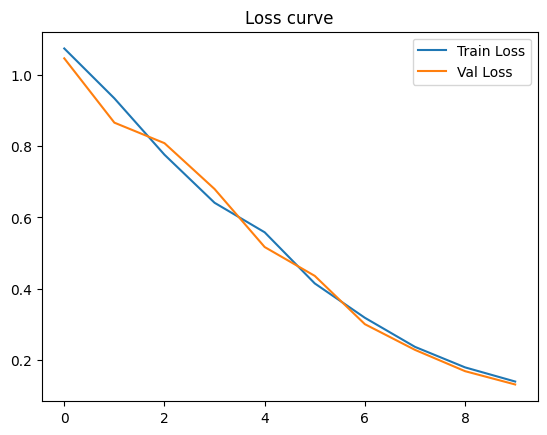

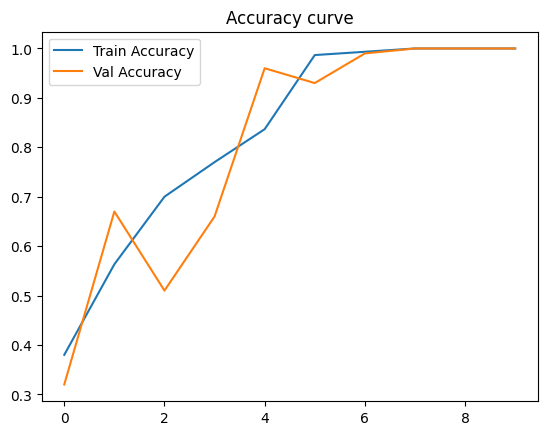

In [11]:
plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       0.95      1.00      0.97        35
           2       1.00      0.97      0.98        33

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



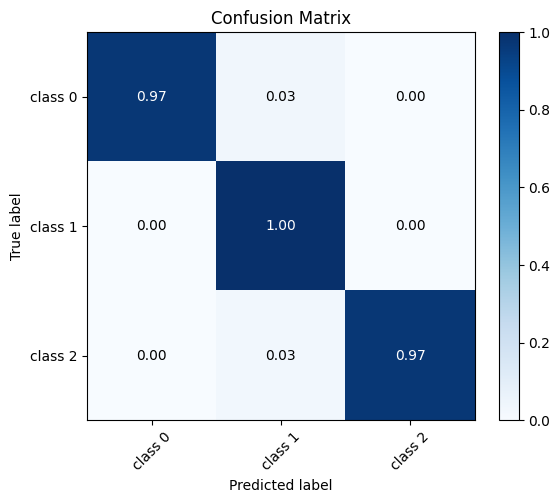

In [12]:
results = evaluate_model(model, test_loader, device)

print("Accuracy:", results["accuracy"])
print(results["report"])

plot_confusion_matrix(results["confusion_matrix"],
                      ["class 0", "class 1", "class 2"])

## 3. Denoising con Autoencoder Variacional (ConvVAE)

- Dataset para mejorar el almacenamiento, procesamiento y gestión de los datos de MNIST (imágenes con ruido, sin ruido, labels, etc.).

In [13]:
class DenoisingMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset
        self.noisy_images = []
        self.clean_images = []

        for img, _ in self.mnist:
            clean_img = img
            noisy_img, _ = apply_mixed_noise(img)
            self.clean_images.append(clean_img)
            self.noisy_images.append(noisy_img)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.clean_images[idx]

In [14]:
train_dataset_dn = DenoisingMNISTDataset(train_subset)
val_dataset_dn = DenoisingMNISTDataset(val_subset)
test_dataset_dn = DenoisingMNISTDataset(X_test)

train_loader_dn = DataLoader(train_dataset_dn, batch_size=32, shuffle=True)
val_loader_dn = DataLoader(val_dataset_dn, batch_size=32, shuffle=False)
test_loader_dn = DataLoader(test_dataset_dn, batch_size=32, shuffle=False)

### 3.1. Estructura del encoder y decoder
El **ConvVAE** no busca simplemente mapear una entrada a una salida, sino comprimir la imagen en un **espacio latente estocástico continuo** gobernado por una distribución normal ideal $\mathcal{N}(0, I)$.

- **Notas importantes:**
  - `fc_mu` y `fc_logvar` definen la media y log-varianza de la distribución latente.
  - El truco de reparametrización permite muestrear $z \sim \mathcal{N}(\mu, \sigma^2)$ mientras se mantiene la diferenciabilidad.
  - El decoder reconstruye la imagen ruidosa hacia la limpia usando `ConvTranspose2d` y activación `Sigmoid`.


In [15]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        # Encoder: 1×28×28 → 64×7×7 → latente
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # → 32×14×14
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # → 64×7×7
            nn.ReLU(),
            nn.Flatten()                                  # → 3136
        )
        self.fc_mu     = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        # Decoder: latente → 64×7×7 → 1×28×28
        self.fc_decode = nn.Linear(latent_dim, 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),                          # → 64×7×7
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # → 32×14×14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),   # → 1×28×28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * torch.randn_like(sigma)

    def decode(self, z):
        return self.decoder(self.fc_decode(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

### 3.2. El truco de la reparametrización
Para que las redes neuronales puedan aprender mediante el algoritmo de retropropagación (backpropagation), el paso de muestreo de la variable latente $z$ no puede ser puramente estocástico. Se implementa el **truco de la reparametrización**, aislando el elemento aleatorio determinista mediante un vector de ruido exógeno $\epsilon$. \1
$$
\sigma = \exp\left(0.5 \cdot \log(\sigma^2)\right)
$$

$$
z = \mu + \sigma \odot \epsilon \quad \text{donde } \epsilon \sim \mathcal{N}(0, I)
$$


La optimización del VAE tradicional busca maximizar la cota inferior evidencial (ELBO). En este script, la función de pérdida combina. \1
- **Entropía Cruzada Binaria (BCE)** como medida de fidelidad de píxeles.
- **Divergencia de Kullback-Leibler (KL)** como regularizador del espacio latente.

Se incorpora un factor de ponderación $\beta = 0.5$ (siguiendo los principios de las arquitecturas $\beta$-VAE). \1
$$
\mathcal{L}_{\text{total}} = \text{BCE}(x, \hat{x}) + \beta \cdot \mathcal{D}_{\text{KL}}\left(\mathcal{N}(\mu, \sigma^2) \parallel \mathcal{N}(0, I)\right)
$$

### Componentes explícitos

- **BCE:**

$$
\text{BCE} = \sum - \left[ x \log \hat{x} + (1 - x) \log (1 - \hat{x}) \right]
$$

- **KL:**

$$
\mathcal{D}_{\text{KL}} = -\frac{1}{2} \sum \left( 1 + \log(\sigma^2) - \mu^2 - \sigma^2 \right)
$$

### Justificación del hiperparámetro $\beta = 0.5$

Al reducir el impacto de la divergencia KL ($\beta < 1$), el modelo **relaja la restricción** de que el espacio latente sea perfectamente gaussiano. Esto prioriza la **calidad y nitidez de la reconstrucción de los píxeles (BCE)**, algo fundamental para la tarea de eliminación extrema de ruido (denoising).

In [16]:
# En la pérdida, el recon_x ya tiene shape (batch, 1, 28, 28)
# def vae_loss(recon_x, x, mu, logvar):
#     bce = F.binary_cross_entropy(recon_x, x, reduction='sum')  # sin .view()
#     kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     return bce + kl

In [17]:
# MEJORA: CON HIPERPARÁMETRO BETA
# en estecaso: bajamos el peso del KL para favorecer la reconstrucción
def vae_loss(recon_x, x, mu, logvar, beta=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kl

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dn = ConvVAE(latent_dim=16).to(device)
optimizer = optim.Adam(model_dn.parameters(), lr=1e-3)
EPOCHS = 15

for epoch in range(1, EPOCHS+1):
    model_dn.train()
    total_loss = 0
    for noisy, clean in train_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model_dn(noisy)
        loss = vae_loss(recon, clean, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader_dn.dataset):.4f}")

Epoch 1 | Loss: 475.1567
Epoch 2 | Loss: 334.5036
Epoch 3 | Loss: 258.5061
Epoch 4 | Loss: 229.3657
Epoch 5 | Loss: 217.8291
Epoch 6 | Loss: 211.9404
Epoch 7 | Loss: 208.9604
Epoch 8 | Loss: 205.7994
Epoch 9 | Loss: 203.1672
Epoch 10 | Loss: 198.2238
Epoch 11 | Loss: 191.2860
Epoch 12 | Loss: 184.4742
Epoch 13 | Loss: 176.0349
Epoch 14 | Loss: 167.5475
Epoch 15 | Loss: 159.3806


- **NOTA IMPORTANTE: SE ESTÁN UTILIZANDO 15 EPOCHS PARA COMPARAR EL COMPORTAMIENTO CLÁSICO VS EL HÍBRIDO CUÁNTICO.**

## 4. Resultados y Conclusiones

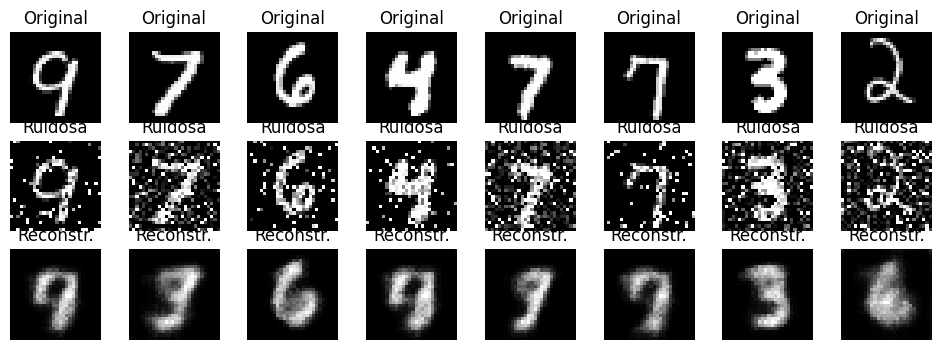

In [19]:
mostrar_reconstrucciones(model_dn, test_dataset_dn, n=8, device=device)      # VAE clásico


- Como podemos observar la reconstrucción de las imágenes es bastante difuminada, limitada y los patrones más complejos, como puede ser diferenciar un 9 de un 4 se complica. Esto se puede deber a que. \1  - Estamos utilziando un dataset pequeño (300 muestras de entrenamiento).
  - Pocas epochs (15). El modelo no converge completamente.
  - Utilizar la función de pérdida de binary_corss_entropy a nivel de píxel: el autoencoder tiende a promediar generando bordes borrosos.

- Además, aunque pusimos beta = 0.5 para reducir el peso de la divergencia KL, se quita del espacio latente la obligación de seguir distribución gaussiana y se prioriza la reconstrucción. Por ello, en las imágenes de salida, vemos poco ruido de fondo (no hay apenas) a parte de bordes borrosos.

### 4.1. Métricas de evaluación

Para medir si el ConvVAE reconstruye las imágenes “limpias” a partir de las ruidosas, se utilizan métricas cuantitativas de error. \1
- #### Mean Squared Error (MSE)
    $$
    \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2
    $$

    Compara píxel a píxel la reconstrucción ($\hat{x}$) con la imagen original ($x$).  
    Valores más bajos indican mejor reconstrucción.


- #### Peak Signal-to-Noise Ratio (PSNR)
    $$
    \text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)
    $$

    donde $\text{MAX}$ es el valor máximo del píxel (para MNIST = 1).  
    Mayor PSNR significa mejor calidad visual.


- #### Structural Similarity Index (SSIM)
    Evalúa similitud estructural entre la imagen original y la reconstruida.  
    Valores cercanos a 1 indican alta similitud.

In [20]:
from sklearn.metrics import mean_squared_error
import torch
import numpy as np

model_dn.eval()
mse_list = []
psnr_list = []

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        recon, _, _ = model_dn(noisy)

        # Convertir a numpy
        recon_np = recon.cpu().numpy()
        clean_np = clean.cpu().numpy()

        # MSE
        mse = ((recon_np - clean_np) ** 2).mean()
        mse_list.append(mse)

        # PSNR
        psnr = 10 * np.log10(1.0 / mse)  # MAX=1 para MNIST
        psnr_list.append(psnr)

print(f"MSE promedio: {np.mean(mse_list):.4f}")
print(f"PSNR promedio: {np.mean(psnr_list):.2f} dB")

MSE promedio: 0.0461
PSNR promedio: 13.37 dB


- EL MSE toma valor de 0.0465: error bajo por pixel. El model es capaz de recuperar bien las estructuras de los dígitos, aunque por el entrenamiento escaso (de datos y epochs) la reconstrucción es débil.
- PSNR de 13.33 dB: normalmente para la reconstrucción de imágenes se piden valores más altos. Esto se puede lograr fácilmente añadiendo epochs, o añadiendo más datos de entrenamiento. El valor obtenido refleja que la reconstrucción es borrosa.

In [21]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

model_dn.eval()
ssim_list = []

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        recon, _, _ = model_dn(noisy)

        # Convertir a numpy y dimension [batch, H, W]
        recon_np = recon.squeeze(1).cpu().numpy()
        clean_np = clean.squeeze(1).cpu().numpy()

        for i in range(recon_np.shape[0]):
            ssim_val = ssim(clean_np[i], recon_np[i], data_range=1.0)
            ssim_list.append(ssim_val)

print(f"SSIM promedio: {np.mean(ssim_list):.4f}")

SSIM promedio: 0.4497


El valor SSIM de 0.4310 está lejos de 1. Justifica que se vean las imágenes reconstruidas borrosas (bordes pocos definidos o se pierden trazos de digitos originales).

## 5. Explicabilidad de la CNN de Clasificación de Ruido

En esta sección utilizaremos distintas técnicas de *Explainable Artificial Intelligence (XAI)* para interpretar cómo la CNN toma decisiones al clasificar tipos de ruido en imágenes.  

**Imports para XAI**

- **Saliency**. \1  Método basado en gradientes que identifica qué píxeles de la imagen tienen mayor influencia en la predicción del modelo.

- **Integrated Gradients**. \1  Técnica de atribución que calcula la contribución de cada píxel integrando gradientes entre una imagen base y la imagen de entrada.

- **Occlusion**. \1  Método basado en perturbaciones que oculta regiones de la imagen para analizar cómo cambia la predicción del modelo.

- **LayerGradCam**. \1  Variante de Grad-CAM que genera mapas de calor utilizando activaciones y gradientes de capas convolucionales específicas.

- **Layer Attribution**. \1  Utilidad auxiliar de Captum que permite adaptar y redimensionar mapas de atribución generados por distintos métodos.

- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**. \1  Técnica de reducción de dimensionalidad no lineal utilizada para visualizar representaciones internas de alta dimensión en 2D o 3D.

- **PCA (Principal Component Analysis)**. \1  Método estadístico de reducción de dimensionalidad que proyecta los datos en las direcciones de máxima varianza.

In [22]:
from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    LayerGradCam,
    LayerAttribution
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import numpy as np

c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\REPOS\qml-mixed-noise-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.1. Visualización de Activaciones Internas
- **Objetivo**: Inspeccionar qué detectan los filtros convolucionales (`conv1`, `conv2`) y analizar cómo la red representa los distintos patrones de ruido.

#### Hooks de PyTorck

In [23]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

hook1 = model.conv1.register_forward_hook(get_activation('conv1'))
hook2 = model.conv2.register_forward_hook(get_activation('conv2'))

- Seleccionar imagen de test

In [24]:
model.eval()

images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

with torch.no_grad():
    pred = model(image).argmax(dim=1).item()

print(f"Clase real: {label}")
print(f"Clase predicha: {pred}")

Clase real: 1
Clase predicha: 1


- Forward pass

In [25]:
_ = model(image)

- Visualización de conv1

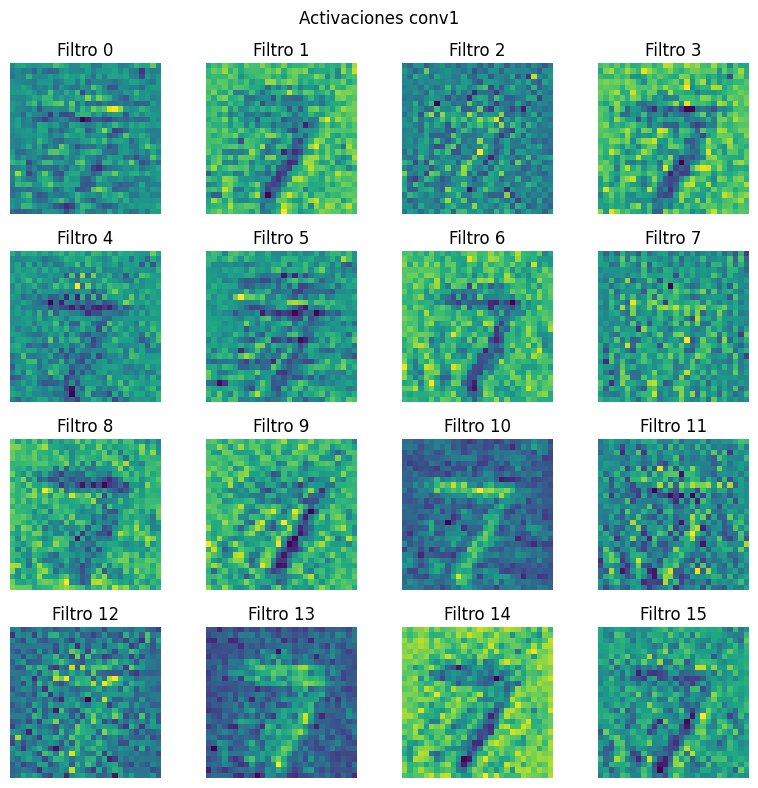

In [26]:
act = activations['conv1'][0]

fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv1")
plt.tight_layout()
plt.show()

- Visualización de conv2

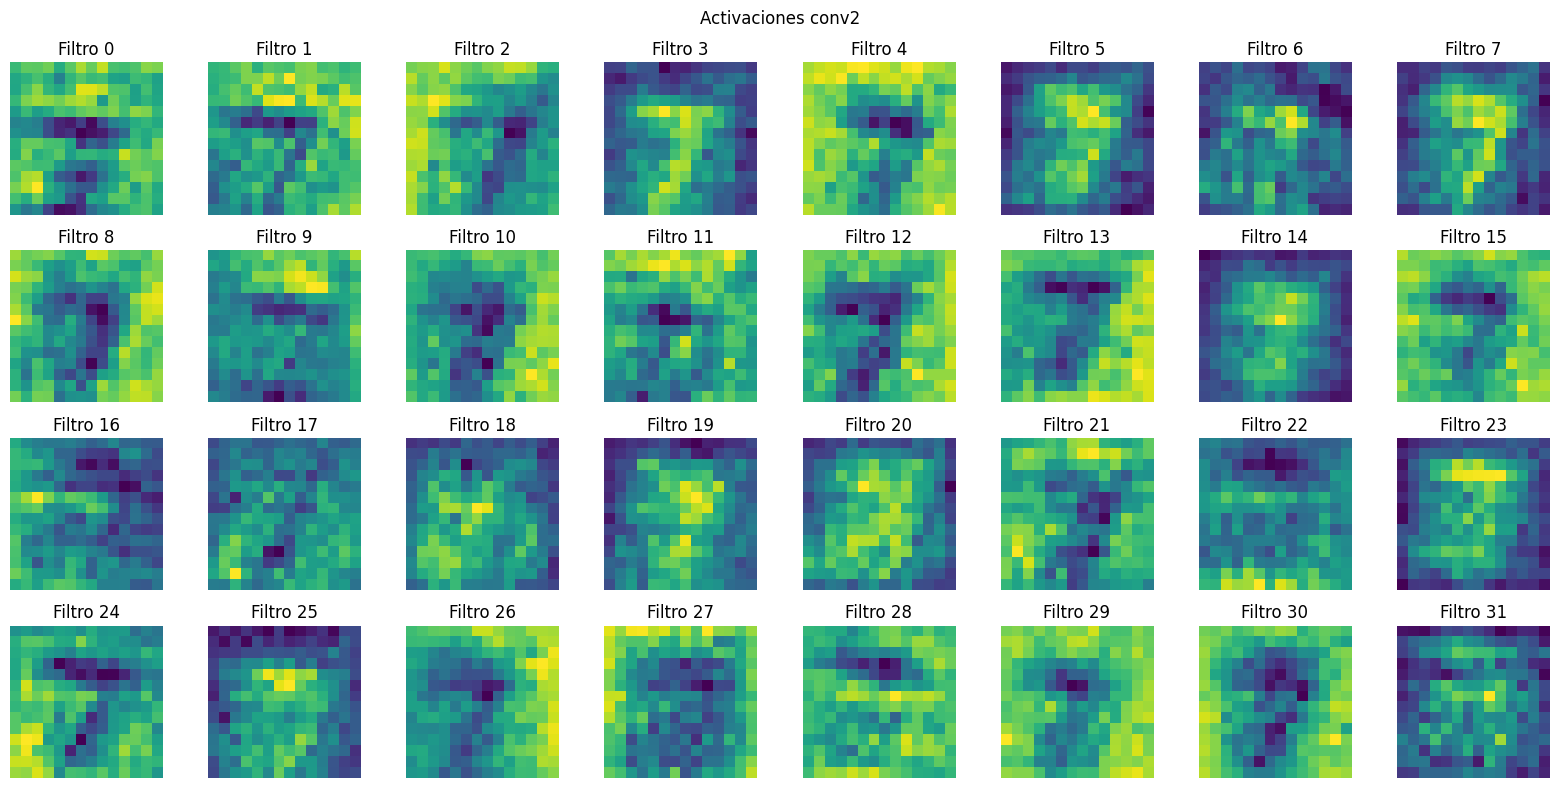

In [27]:
act = activations['conv2'][0]

fig, axes = plt.subplots(4,8, figsize=(16,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv2")
plt.tight_layout()
plt.show()

- **Interpretación de activaciones**
    - Las primeras capas convolucionales (conv1) responden principalmente a patrones locales de alta frecuencia generados por el ruido impulsivo y los bordes de los dígitos. La silueta del 7 es reconocible en la mayoría de los canales (ej. Filtros 1, 5, 6 y 14). Esto demuestra que la red conserva la información espacial base mientras analiza las perturbaciones.

    - Por otro lado, las activaciones de conv2 muestran representaciones más abstractas y distribuidas espacialmente, indicando que la red aprende estructuras asociadas a combinaciones específicas de ruido. Filtros de Forma (ej. Filtros 3, 7, 21 y 23): Se concentran específicamente en los palos del dígito (la barra horizontal superior y la diagonal del 7).

    - El ruido de sal y pimienta produce activaciones más localizadas e intensas, mientras que el ruido gaussiano genera respuestas más suaves y distribuidas.

### 5.2. Saliency Maps

- **Objetivo**: Identificar qué píxeles afectan más a la clasificación

- Inicializamos Saliency

In [28]:
saliency = Saliency(model)

- Gradientes

In [29]:
image.requires_grad = True

attribution = saliency.attribute(image, target=pred)

attr = attribution.squeeze().cpu().detach().numpy()

- Visualización

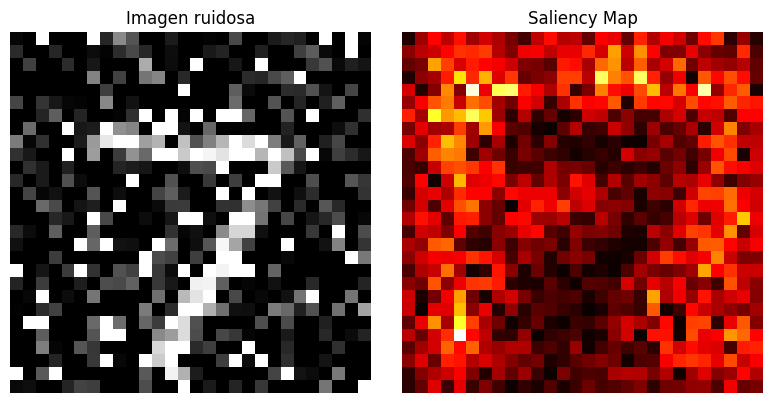

In [30]:
fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(attr, cmap='hot')
axes[1].set_title("Saliency Map")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

- **Interpretación**. \1    - Los mapas de saliencia muestran las regiones cuya modificación alteraría más la predicción de la red.
    - En este problema, la CNN no aprende únicamente estructuras semánticas del dígito, sino patrones estadísticos asociados al ruido.
    - Las regiones con ruido impulsivo generan gradientes más intensos debido a sus discontinuidades abruptas.

### 5.3. Integrated Gradients
- **Objetivo**: Reducir el ruido visual presente en Saliency Maps.

- Inicializar IG

In [31]:
ig = IntegratedGradients(model)

- Calcular atribuciones

In [32]:
attr_ig = ig.attribute(
    image,
    target=pred,
    n_steps=50
)

attr_ig = attr_ig.squeeze().cpu().detach().numpy()

- Visualización

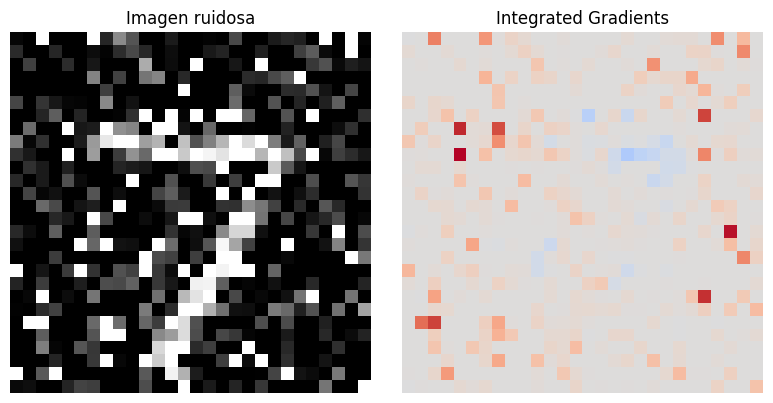

In [75]:
max_val = np.max(np.abs(attr_ig))

fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(
    attr_ig,
    cmap='coolwarm',
    vmin=-max_val,
    vmax=max_val
)

axes[1].set_title("Integrated Gradients")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

- **Interpretación**. \1    - Integrated Gradients produce explicaciones más suaves y menos ruidosas que Saliency Maps.
    - Las atribuciones positivas (rojo) corresponden a regiones que favorecen la clase predicha, mientras que las negativas (azul) reducen dicha probabilidad. Entonces, podemos observar que la red está aprenidendo exáctamente de los ruidos generados en la imagen (zonas más rojas).

### 5.4. Grad-CAM
- **Objetivo**: Localizar espacialmente qué regiones dominan la clasificación.


- Inicializamos LayerGradCam

In [34]:
gradcam = LayerGradCam(model, model.conv2)

- Calculamos mapa

In [35]:
attr_gc = gradcam.attribute(image, target=pred)

- Upsampling al tamaño original

In [36]:
attr_gc_up = LayerAttribution.interpolate(
    attr_gc,
    image.shape[2:]
)

heatmap = attr_gc_up.squeeze().cpu().detach().numpy()

- Visualización

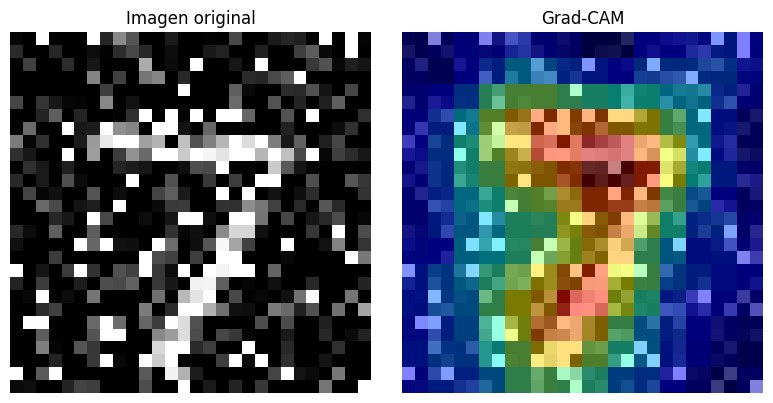

In [37]:
fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen original")

axes[1].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

- **Interpretación**. \1    - Grad-CAM permite visualizar las regiones espaciales más relevantes para la clasificación del tipo de ruido.
    - A diferencia de las técnicas basadas puramente en gradientes de píxel, Grad-CAM utiliza activaciones convolucionales profundas, proporcionando explicaciones más semánticas y menos sensibles al ruido local.
    - En este problema, se observa que el modelo atiende especialmente a regiones donde las perturbaciones estadísticas son más intensas (ES DECIR, EL DÍGITO EN SÍ + PERTURBACIONES SOBRE ÉSTE).
    - máxima activación (zona roja/marrón) se concentra sobre la barra horizontal superior del 7 y el palo tumbado. La red ha aprendido que debe mirar zonas donde hay píxeles blancos (del dígito SÓLAMENTE).
    - El fondo de la imagen se mantiene en azul absoluto. Esto demuestra que el modelo ignora el ruido aislado y prefiere evaluar el ruido aplicado al dígito.
    - Al extraer la información de la capa conv2 (que ha pasado por operaciones de Pooling), la resolución es más baja.

### 5.5. Occlusion Sensitivity
- **Objetivo**: Evaluar robustez espacial mediante perturbaciones.

- Inicializar Occlusion

In [38]:
occlusion = Occlusion(model)

- Atribuciones

In [39]:
attr_occ = occlusion.attribute(
    image,
    strides=(1,4,4),
    target=pred,
    sliding_window_shapes=(1,4,4),
    baselines=0
)

attr_occ = attr_occ.squeeze().cpu().detach().numpy()

- Visualización

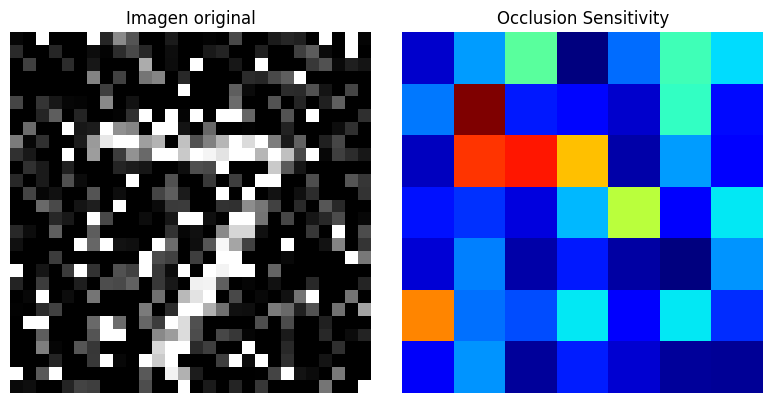

In [40]:
fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(image.squeeze().cpu().detach(), cmap='gray')
axes[0].set_title("Imagen original")

axes[1].imshow(attr_occ, cmap='jet')
axes[1].set_title("Occlusion Sensitivity")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

-  Tamaño de ventana de $4 \times 4$ y un salto (stride) de $4 \times 4$, la imagen original de $28 \times 28$ píxeles queda dividida exactamente en una matriz discreta de $7 \times 7$ bloques.

- **Interpretación**. \1
    - La técnica de oclusión analiza cómo varía la predicción cuando distintas regiones de la imagen son eliminadas.
    - Esto permite estudiar si la red depende de patrones locales específicos o de distribuciones globales del ruido.
    - Los resultados muestran que zonas con ruido impulsivo tienen una influencia mayor sobre la decisión final.
- La zona de máxima sensibilidad se localiza en la intersección superior izquierda del número 7 (fila 2, columna 2 de la cuadrícula) y se extiende horizontalmente por la barra del dígito. Tapar esta región destruye la capacidad de la CNN para evaluar el ruido. Además, la red en la fila 6 columna 1, encuentra una zona también importante para la clasificación del ruido mixto.

### 5.6. Visualización del Espacio Latente de 4 Dimensiones

- **ESTA ES LA SECCIÓN MÁS IMPORTANTE para vuestra futura comparación con CQNN.**

- Extraer embeddings

In [41]:
model.eval()

latent_vectors = []
latent_labels = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        x1 = F.relu(model.conv1(x))
        x1 = model.pool(x1)

        x1 = F.relu(model.conv2(x1))
        x1 = model.pool(x1)

        x1 = x1.view(x1.size(0), -1)

        x1 = F.relu(model.fc1(x1))

        latent = torch.tanh(model.fc2(x1)) * np.pi

        latent_vectors.append(latent.cpu().numpy())
        latent_labels.append(y.numpy())

latent_vectors = np.concatenate(latent_vectors)
latent_labels = np.concatenate(latent_labels)

- t-SNE

In [42]:
tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42
)

latent_2d = tsne.fit_transform(latent_vectors)

- Visualización

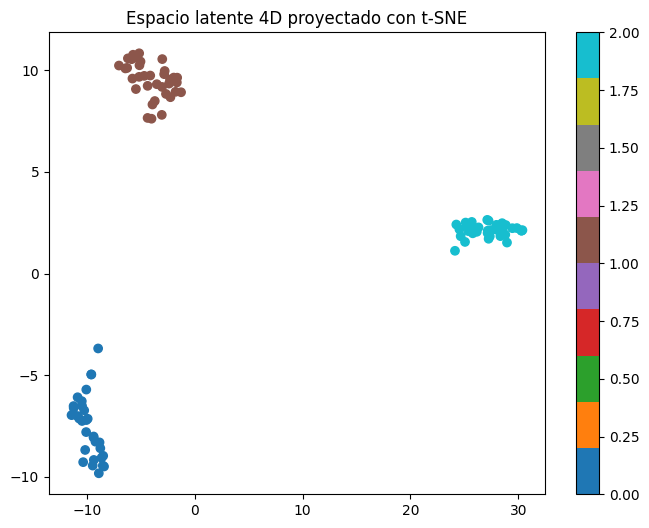

In [43]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=latent_labels,
    cmap='tab10'
)

plt.colorbar(scatter)
plt.title("Espacio latente 4D proyectado con t-SNE")
plt.show()

- **Interpretación**
    - La proyección t-SNE del espacio latente muestra cómo la red organiza internamente las distintas combinaciones de ruido.
    - La separación observada entre clusters indica que el embedding de 4 dimensiones captura información discriminativa para distinguir patrones complejos.
    - Este análisis será relevante para comparar posteriormente el comportamiento del embedding híbrido cuántico.
- Hay separabilidad casi perfecta. La varianza intra-clase es pequeña con la distancia inter-clase. La CNN clásica separa bien las característias para clasificar ruidos mixtos (son linealmente separables en el espacio 4D).

### 5.7. Análisis de errores
- **Objetivo**: Encontrar errores

In [44]:
model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        out = model(x)

        preds = out.argmax(dim=1).cpu()

        wrong = preds != y

        wrong_images.extend(x.cpu()[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(y[wrong])

- Visualizar errores

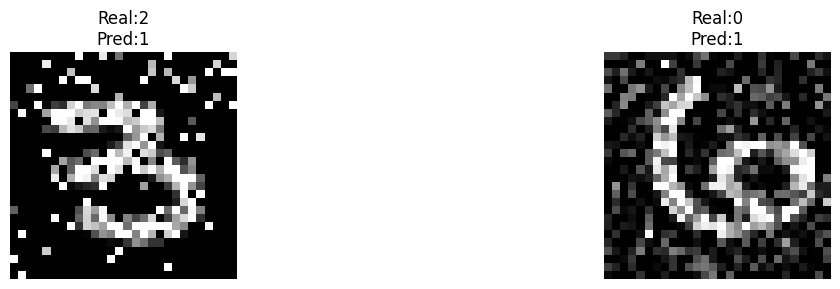

In [45]:
n = min(5, len(wrong_images))

if n == 0:
    print("No se encontraron errores de clasificación.")
else:

    fig, axes = plt.subplots(1, n, figsize=(15,3))

    # cuando n=1 matplotlib no devuelve lista
    if n == 1:
        axes = [axes]

    for i in range(n):

        axes[i].imshow(
            wrong_images[i].squeeze(),
            cmap='gray'
        )

        axes[i].set_title(
            f"Real:{wrong_labels[i]}\nPred:{wrong_preds[i]}"
        )

        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

- En algunas ejecuciones no aparecen errores de clasificación debido al tamaño reducido del dataset de test (100 muestras) y a la relativa simplicidad del problema. Esto limita parcialmente el análisis de errores, aunque confirma que la CNN logra separar los patrones de ruido en este subconjunto.

**Discusión**. \1- Los errores del clasificador aparecen principalmente en muestras donde las propiedades estadísticas de dos tipos de ruido se superponen significativamente (ocurre entre las 3 clases).
- Esto sugiere que ciertas combinaciones de degradación producen representaciones ambiguas incluso para modelos convolucionales clásicos.
- El análisis XAI permite verificar si estas confusiones provienen de regiones específicas de la imagen o de distribuciones globales similares del ruido. 
- En estos 2 casos, la CNN no ha sido capaz de encontrar bien características de las imágenes capaces de separar e identificar a la clase que corresponden.

### 5.8. LIME para explicación local de clasificación de ruido
- **Objetivo**: Hasta ahora, las técnicas aplicadas (Saliency, IG, Grad-CAM, etc.) eran principalmente métodos white-box, es decir, necesitan acceso interno a la red (gradientes, activaciones, pesos). Ahora aplicaremos LIME (Local Interpretable Model-agnostic Explanations), que es un método. \1    - Model-agnostic (caja negra).
    - Basado en perturbaciones.
    - Explica decisiones concretas mediante regiones importantes de la imagen.
- Pasos a seguir. \1    1. Segmentar la imagen en regiones (superpíxeles).
    2. Ocultar aleatoriamente algunas regiones.
    3. Ver cómo cambia la predicción del modelo.
    4. Ajustar un modelo lineal interpretable localmente.

- En nuestro problema, buscamos que LIME nos responda a preguntas como. \1    - ¿Qué zonas utiliza la CNN para reconocer ruido gaussiano?
    - ¿El modelo se fija en impulsos aislados?
    - ¿Qué regiones distinguen el ruido speckle del salt & pepper?

In [46]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.segmentation import slic

- **Función puente para LIME**: LIME trabaja con imágenes RGB en formato NumPy `(H, W, 3)` pero nuestro modelo espera tensores PyTorch `(B, 1, 28, 28)`. Entonces, necesitamos una función intermedia.

In [47]:
def predict_lime(images):
    model.eval()

    # RGB -> grayscale
    images_gray = np.mean(images, axis=-1, keepdims=True)

    # Normalización
    images_gray = images_gray.astype(np.float32)

    # Convertir a tensor PyTorch
    tensor = torch.tensor(images_gray).permute(0,3,1,2).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

- Selección de imagen de test (usamos una imagen correctamente clasificada)

In [48]:
model.eval()

for noisy_img, label in test_dataset:
    
    x = noisy_img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).argmax(1).item()

    if pred == label:
        image_test = noisy_img
        label_real = label
        label_pred = pred
        break

- Conversión a RGB:

In [49]:
img_np = image_test.squeeze().cpu().numpy()
img_rgb = np.stack([img_np]*3, axis=-1)

- Inicializamos el explicador de LIME:

In [50]:
explainer = lime_image.LimeImageExplainer()

- Segmentación: Usamos pocos superpíxeles porque MNIST es pequeño.
- Los superpíxeles permiten visualizar: regiones ruidosas importantes, patrones espaciales relevantes, diferencias entre tipos de ruido.

In [51]:
segmenter = lambda x: slic(
    x,
    n_segments=20,
    compactness=5,
    start_label=1
)

- Generamos explicaciones

In [52]:
explanation = explainer.explain_instance(
    img_rgb,
    predict_lime,
    top_labels=3,
    hide_color=0,
    num_samples=500,
    segmentation_fn=segmenter
)

100%|██████████| 500/500 [00:00<00:00, 4065.05it/s]


- Visualización

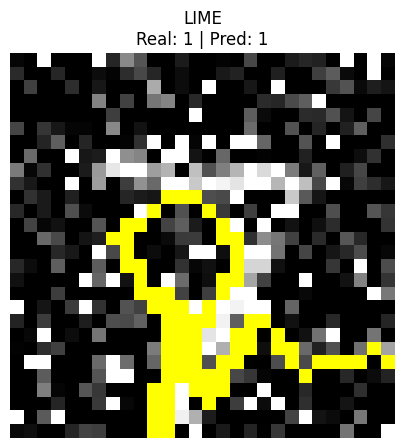

In [53]:
temp, mask = explanation.get_image_and_mask(
    label_pred,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp, mask))
plt.title(
    f"LIME\nReal: {label_real} | Pred: {label_pred}"
)
plt.axis('off')
plt.show()

- Con esta imagen (dígito 7), se puede explicar. \1    - La máscara amarilla resalta las características con mayor peso positivo. El ancla de la clasificación (zona amarilla) es la parte inferior de la diagonal y se extiende por el fondo inferior derecho.
    - Hemos configurado compactness = 5 provocando que las fronteras de los superpíxeles no sean cuadrados exactos, sino que sigan los gradientes (ayuda a considerar dígito (trazo blanco) con el ruido de alrededor).

- **Interpretación**. \1    - Clase 0 (Gaussian + Speckle). \1        - zonas con grano fino,
        - patrones multiplicativos,
        - regiones de textura homogénea alteradas.
    - Clase 1 (Gaussian + Salt&Pepper). \1        - píxeles extremos blancos/negros,
        - impulsos aislados,
        - discontinuidades abruptas.
    - Clase 2 (Salt&Pepper + Speckle). \1        - regiones impulsivas,
        - áreas rugosas,
        - zonas de alto contraste local.

    - LIME al ser un model caja negra no necesita de gradientes o pesos internos esto es importante porque al comparar con la CQNN híbrida, los circuitos cuánticos no tienen gradientes interpretables fácilmente o pueden ser opacos.
    - Limitaciones: Como MNIST tiene imágenes de resolución baja (28x28), la segmentación puede generar regiones demasiados grandes. Además, LIME es inestable al depender de pertubaciones aleatorias, segmentaciones, etc. por lo que en distintas ejecuciones podemos observar explicaciones diferentes.
    - LIME es lento porque necesita muchas inferencias y muchas perturbaciones. Si utilizaramos inferencias cuánticas (mucho más caras computacionalmente), LIME se volvería más lento aún.

### 5.9. SHAP / DeepLIFT para atribución de píxeles en clasificación de ruido
- **Objetivo**. \1    - Aplicaremos ahora SHAP GradientExplainer, que se basa en propagación de relevancia, contribuciones aditivas y en teoría de valores de Shapley.
- SHAP GradientExlainer implementa una aproximación cercana a DeepLIFT, Layer-wise Relevance Propagation (LRP). 

- **Aportaciones de SHAP**. \1    - Conocer qué píxeles aumentan la probabilidad de una clase de ruido. Además de saber las regiones que empujan la predicción hacia otra clase. 

- A diferencia de métodos como Saliency donode la explicabilidad es de sensibilidad local o Grad-CAM centrado en regiones convolucionales, con SHAP se busca explicar la contribución aditiva aproximada. Para ello, SHAP genera mapas donde. \1    - **rojo**: contribuye positivamente a la clase.
    - **azul**: contribución negativa.
    - **intensidad**: magnitud de la contribución.

In [54]:
import shap

# SHAP funciona mejor en modo evaluación:
model.eval()

ClassicalNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (feature_mixer): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

- **Selección del background**. \1    - SHAP necesita ejemplos de referencia. Utilizaremos imágenes ruidosas del train set.

In [55]:
background = []

for i in range(50):
    img, _ = train_dataset[i]
    background.append(img.numpy())

background = np.array(background)

print(background.shape)

(50, 1, 28, 28)


- Necesitamos crear un wrapper de pytorch a numpy, pues GradientExplainer necesita una función compatible.

In [56]:
def model_predict(x_numpy):

    x_tensor = torch.tensor(
        x_numpy,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        out = model(x_tensor)
        probs = torch.softmax(out, dim=1)

    return probs.cpu().numpy()

- Selección de imagen de test

In [57]:
image_test, label_real = test_dataset[0]
image_batch = image_test.unsqueeze(0).numpy()

- Inicialización del explicador

In [58]:
explainer = shap.GradientExplainer(
    model,
    torch.tensor(background, dtype=torch.float32).to(device)
)

- Calculamos valores SHAP

In [59]:
shap_values = explainer.shap_values(
    torch.tensor(image_batch, dtype=torch.float32).to(device)
)

- Extracción del mapa correspondiente (SHAP puede devolver formatos distintos según su versión)
    - Se añade doble verificación para evitar errorres.

In [60]:
print(type(shap_values))

if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(1, 1, 28, 28, 3)


In [61]:
if isinstance(shap_values, list):
    map_shap = shap_values[label_real][0,0]
else:
    map_shap = shap_values[0,0,:,:,label_real]

- Visualización

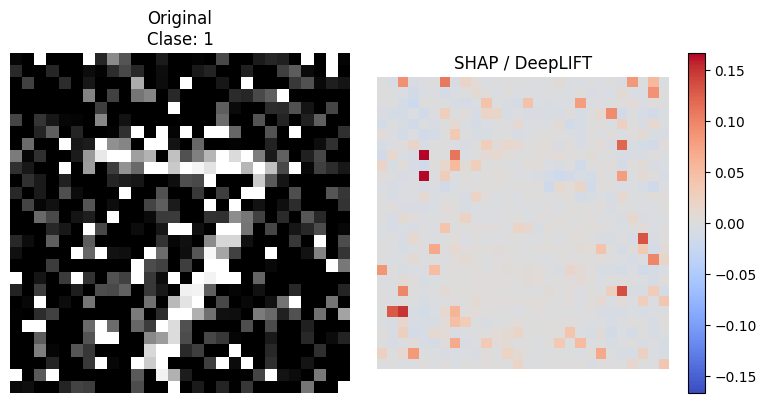

In [62]:
max_val = np.max(np.abs(map_shap))

fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(
    image_test.squeeze(),
    cmap='gray'
)

axes[0].set_title(
    f"Original\nClase: {label_real}"
)

im = axes[1].imshow(
    map_shap,
    cmap='coolwarm',
    vmin=-max_val,
    vmax=max_val
)

axes[1].set_title("SHAP / DeepLIFT")

for ax in axes:
    ax.axis('off')

plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

- En este caso, el ruido mixto del fondo del dígito 7, está siendo lo que aporta mayor peso a la predicción. Es uno de los objetivos de la clasificación de la CNN.

- **Interpretación**. \1    - Regiones rojas: pixeles favorecen a la predicción indicada y que hay estructuras asociadas al tipo de ruido.
    - Por ejemplo. \1        - En Gaussian + Salt and Pepper, SHAP destaca impulsos extremos y ruido de mayor frecuencia. 
        - En Gaussian + Speckle, SHAP destaca texturas distribuidas y variaciones.
        - En Salt and Pepper + Speckle, SHAP destaca regiones donde se mezcla granularidad e impulsos.
    - SHAP es relevante para comparación clásica vs híbrida cuántica, pues. \1        - SHAP no depende explícitamente de las convoluciones realizadas.
        - aplicable en ambos modelos.
        - permite comparar distribuciones de relevancia (según los resultados obtenidos).
    - Limitaciones. \1        1. SHAP es costoso (backward passes, etc.) por lo que será más costos aún en el modelo híbrido cuántico.
        2. Los resultados dependen del background escogido.
    - **Hipótesis planteada a validar**. \1        - CNN clásica puede producir relevancia espacial más suave, patrones más distribuidos. CQNN híbrida podría producir relevancia más concentrada, regiones más discretas, sensibilidad distinta al ruido.

### 5.10. Comparativa global de métodos XAI aplicados a la CNN clásica

- **Objetivo**: Después de aplicar múltiples técnicas de explicabilidad sobre la CNN clásica de clasificación de ruido, es importante realizar una comparación crítica de. \1    - qué explica cada método
    - qué limitaciones tiene
    - qué información aporta realmente
    - cuáles serán transferibles al modelo híbrido cuántico.

- **Durante el estudio de la CNN clásica hemos utilizado**. \1    | Técnica                       | Tipo                     |
    | ----------------------------- | ------------------------ |
    | Visualización de activaciones | Inspección interna       |
    | Saliency Maps                 | Gradiente                |
    | Integrated Gradients          | Gradiente axiomático     |
    | DeconvNet                     | Backprop modificada      |
    | Oclusión                      | Perturbación             |
    | Grad-CAM                      | Activaciones + gradiente |
    | LIME                          | Caja negra               |
    | SHAP                          | Relevancia               |


- **Comparativa conceptual**. \1    | Método               | Caja blanca/negra | Resolución | Coste    | Específico de clase | Interpretabilidad |
    | -------------------- | ----------------- | ---------- | -------- | ------------------- | ----------------- |
    | Activaciones         | Blanca            | Media      | Baja     | No                  | Media             |
    | Saliency             | Blanca            | Alta       | Muy bajo | Sí                  | Baja-media        |
    | Integrated Gradients | Blanca            | Alta       | Medio    | Sí                  | Alta              |
    | DeconvNet            | Blanca            | Alta       | Medio    | Parcial             | Media             |
    | Oclusión             | Negra             | Media      | Muy alto | Sí                  | Alta              |
    | Grad-CAM             | Blanca            | Baja-media | Bajo     | Sí                  | Muy alta          |
    | LIME                 | Negra             | Media      | Muy alto | Sí                  | Alta              |
    | SHAP                 | Blanca            | Alta       | Muy alto | Sí                  | Muy alta          |




- **Conclusiones generales**
    - Los mapas mostraron diferencias claras. \1        | Ruido         | Patrón visual dominante     |
        | ------------- | --------------------------- |
        | Gaussiano     | Variaciones suaves          |
        | Salt & Pepper | Impulsos extremos           |
        | Speckle       | Granularidad multiplicativa |
    
    - Métodos como Saliency o DeconvNet son más ruidosos porque usan gradientes locales y son sensbiles a perturbaciones.
    - Integrated Gradients ha sido más estable: regiones más coherentes, menos ruido, atribuciones más interpretables. Es un buen método candidato a utilizar para comparar la classical CNN vs CQNN.
    - Grad-CAM ha sido intuitivo porque localizó regiones relevantes, entendiendo la decisión de clasificación. Es útil para visualización del usuario y hacer el análisis comparativo.
    - LIME y SHAP aportan interpretabilidad que no depende del modelo, entonces es CRÍTICO para la comparativa con el modelo híbrido clásico cuántico.

    - Cabe destacar que, esta CNN está creada para simular la arquitectura del modelo híbrido cuántico. Entonces, cuando hacemos
        ```python
        x = torch.tanh(self.fc2(x)) * np.pi
        ```
        estamos ya restrigiendo el espacio, emulando los ángulos cuánticos y comprimiendo mucho la información. Esto ayuda a entender que en ocasiones las explicaciones han sido más compactas.

    - Para concluir, con las técnicas de XAI aplicadas a la CNN  se mostraron. \1        - patrones interpretables,
        - localización coherente del ruido,
        - representaciones espaciales razonables.


## 6. Explicabilidad del ConvVAE para denoising de imágenes.
- **Objetivo**: explicabilidad e interpretabilidad del ConvVAE, encargado del denoising.
- En denoising, el modelo genera una imagen, reconstruyéndola. 
- Necesitamos dar interpretabilidad y explicaciones para resolver cuestiones como. \1    - ¿Qué regiones del ruido elimina el VAE?
    - ¿Qué partes conserva?
    - ¿Qué estructura codifica el espacio latente?
    - ¿Qué información pierde durante la compresión?
- Para ello, en esta sección, se organiza de la siguiente manera el notebook. \1    | Pregunta                                       | Técnica             |
    | ---------------------------------------------- | ------------------- |
    | ¿Qué codifica el encoder?                      | Espacio latente     |
    | ¿Qué regiones afectan más a la reconstrucción? | Saliency            |
    | ¿Qué partes se pierden?                        | Error residual      |
    | ¿Cómo se organiza el espacio latente?          | PCA/t-SNE           |
    | ¿Qué “imagina” el decoder?                     | Traversals latentes |


- Diferencia importante respecto a CNN: En la CNN teníamos una imagen y se clasificaba (imagen -> clase). En el VAE, a partir de las imagenes ruidosas generadas en el dataset antes de entrenar la CNN, se comprimen a un espacio latente para posteriormente reconstruir las imágenes sin ruido aplicado.  
    - Ahora, el foco de interpretabilidad está en el encoder, el espacio latente y el decoder.

- En el VAE, el parámetro $\beta$, se establece con `beta=0.5`. Esto afecta a la interpretabilidad, pues. \1    - Cuando $\beta$ es más bajo, la reconstrucción es mejor, más detallada y el espacio latente es más regular. Sin embargo, cuando $\beta$ es mayor, se consigue una mejor organización del espacio latente, hay más desacoplamiento, y el espacio latente es más estable.
        *Desacoplamiento: cada dimensión del espacio latente se encarga de controlar una sola característica de los datos.
    - En nuestro caso, con `beta=0.5`, hemos querido que el modelo priorice la reconstrucción visual para obtener mejores dígitos (a pesar de tener un espacio latente menos separable).
    - El objetivo final, tras terminar el análisis de este notebook, es hacer una comparativa para la reconstrucción de imágenes con ruido mixto con un VQAE. Actualmente, no hay literatura apenas sobre XAI de VQAE híbridos. Además, como los espacios latentes cuánticos son poco interpretables, se podría aportar una análisis original. Una de las hipótesis a validar sería. \1        - El ConvVAE clásico aprende representaciones suaves, más redunatesn y continuas. Mientras que el VQAE aprende espacios más comprimidos y representaciones más discretas.

- El encoder debe aprender sobre la estructura del dígito, ser capaz de separar el ruido y se encarga de la regularización del espacio latente.
- Con el análisis de interpretabilidad del clásico VAE trataremos de explicar qué elimina el modelo: impulsos, granularidad, variaciones, bordes, curvas, etc. El VAE debe conservar la estructura global, detalles y la continuidad espacial; es una tarea más compleja que la de clasificar el ruido mixto de la CNN. Por ello, la tarea de interpretabilidad ahora es más compleja.

### Visualización de reconstrucciones y análisis cualitativo del denoising

- **Objetivo**. \1  - interpretar el modelo generativo observando directamente sus reconstrucciones. Así, podemos analizar qué ruido se está eliminando, qué estructuras se conservan, información perdida, etc.
  - es una técnica fundamental de interpretabilidad para VAEs porque la salida del modelo ES explicación (refleja qué considera el encoder importante, información descartada, etc.).
  - Comparamos: imagen ruidosa (entrada) vs imagen reconstruida (output).

- Visualización:

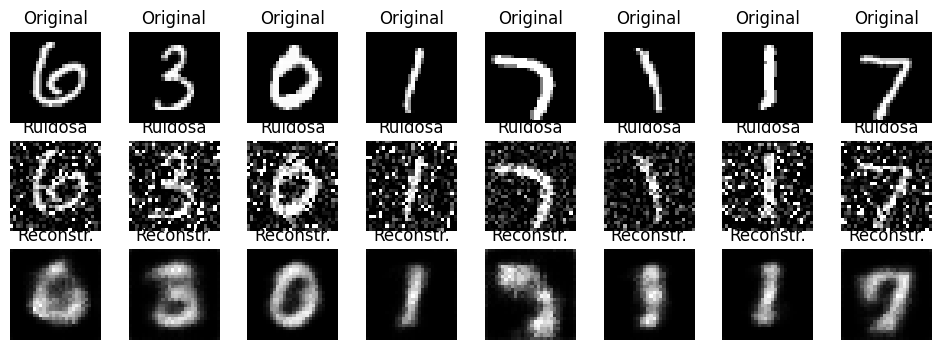

In [63]:
mostrar_reconstrucciones(model_dn, test_dataset_dn, n=8, device=device)

- Selección manual de ejemplos:

In [64]:
model_dn.eval()
examples = []

for i in range(8):
    noisy, clean = test_dataset_dn[i]
    examples.append((
        noisy.unsqueeze(0).to(device),
        clean
    ))

- Reconstrucciones detalladas

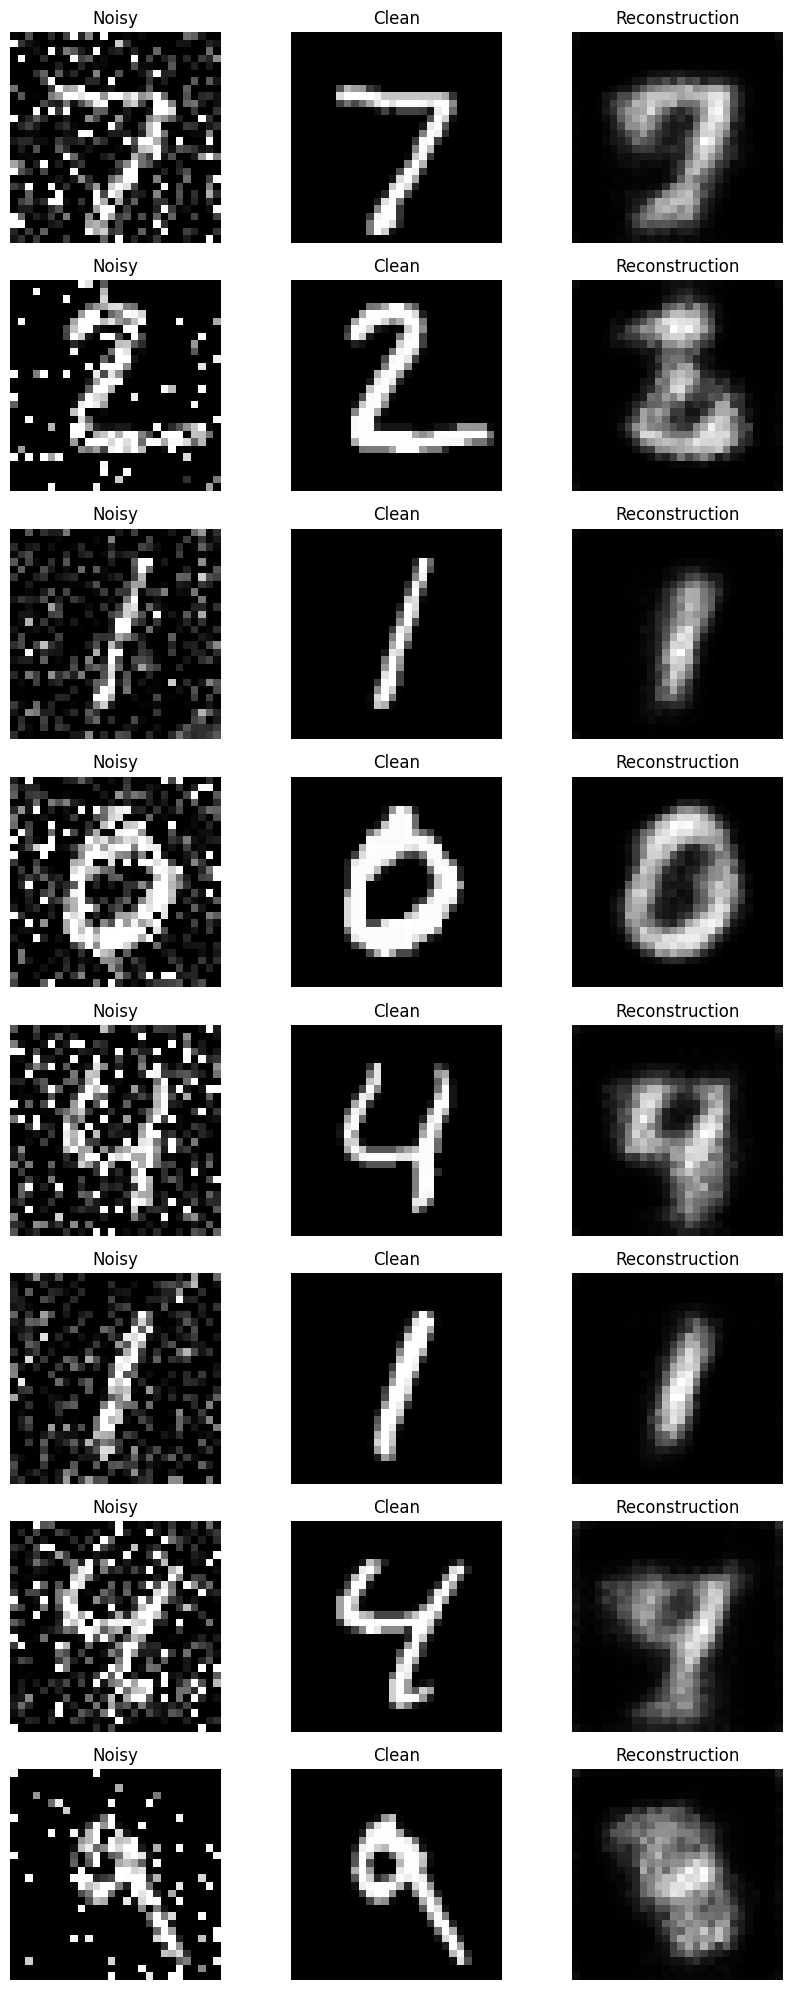

In [65]:
fig, axes = plt.subplots(8, 3, figsize=(9, 20))

with torch.no_grad():

    for i, (noisy, clean) in enumerate(examples):

        recon, mu, logvar = model_dn(noisy)

        noisy_np = noisy.squeeze().cpu().numpy()
        clean_np = clean.squeeze().cpu().numpy()
        recon_np = recon.squeeze().cpu().numpy()

        # Imagen ruidosa
        axes[i,0].imshow(noisy_np, cmap='gray')
        axes[i,0].set_title("Noisy")

        # Imagen limpia
        axes[i,1].imshow(clean_np, cmap='gray')
        axes[i,1].set_title("Clean")

        # Reconstrucción
        axes[i,2].imshow(recon_np, cmap='gray')
        axes[i,2].set_title("Reconstruction")

        for j in range(3):
            axes[i,j].axis('off')

plt.tight_layout()
plt.show()

- **Análisis de resultados**. \1    - Eliminación de ruido. \1        - Gaussian noise: el modelo suaviza correctamente.
        - Salt & Pepper: se eliminan impulsos blancos/negros.
        - Speckle: se ha reducido granularidad.
    - Conservación estructural de los dígitos: se mantienn bordes, curvas, aunque zonas finas más difuminadas (pocas epochs para la comparativa con el modelo híbrido cuántico).
    - El blur es entendible en el VAE porque, aparte de optimizar BCE promedio, el modelo está entrenado con 15 epochs sólamente y se comprime en el espacio latente mucho la información.
    - Además, hemos utilizado binary cross entropy: favorece promedios de píxeles (outputs más suavizados).
    - Con `beta=0.5`, hay menor regularización KL para favorecer reconstrucción. Como se explicó anteriormente.
    - Hay dígitos que se reconstruyen peor, como el 4 y el 7 (confusión en ocasiones).

#### 6.1. Visualización del espacio latente
- **Objetivo**: studiar cómo el encoder organiza las imágenes degradadas dentro del espacio latente.

- Extracción de variables latentes

In [66]:
latent_vectors = []
labels_noise = []

model_dn.eval()

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy = noisy.to(device)

        mu, logvar = model_dn.encode(noisy)

        latent_vectors.append(mu.cpu())
        
        # aquí guardamos la imagen limpia o ruido
        labels_noise.extend(range(len(mu)))

latent_vectors = torch.cat(latent_vectors).numpy()

print(latent_vectors.shape)

(100, 16)


- Si el modelo aprende correctamente. \1
imágenes similares deberían agruparse,
tipos de ruido parecidos deberían quedar próximos,
y diferentes estructuras visuales deberían separarse geométricamente.

### 6.2. Organización del espacio latente con PCA
- **Objetivo**: Reducimos el espacio latente a 2 dimensiones para observar agrupamientos, continuidad, separabilidad, estructura geométrica.

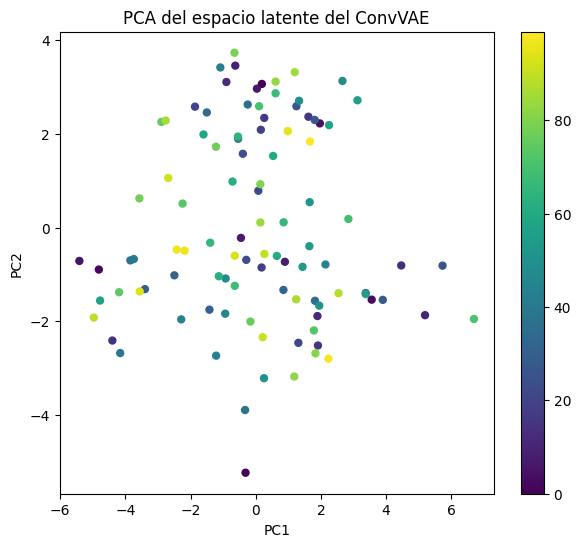

In [67]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=np.arange(len(latent_2d)),
    cmap='viridis',
    s=25
)

plt.colorbar(scatter)
plt.title("PCA del espacio latente del ConvVAE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

- **Interpretación**
    - El espacio latente muestra una estructura continua y relativamente organizada.
    - Las imágenes similares tienden a agruparse en regiones cercanas, indicando que el encoder ha aprendido una representación comprimida coherente.Sin embargo, no aparecen clusters perfectamente separados, existe solapamiento. Esto es esperable debido al tamaño reducido del dataset y al bajo número de epochs.

### 6.3. t-SNE del espacio latente

- **Objetivo**: PCA es lineal. t-SNE permite observar relaciones no lineales entre embeddings.

C:\Users\SergioHF\AppData\Local\Temp\ipykernel_9408\2523600722.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


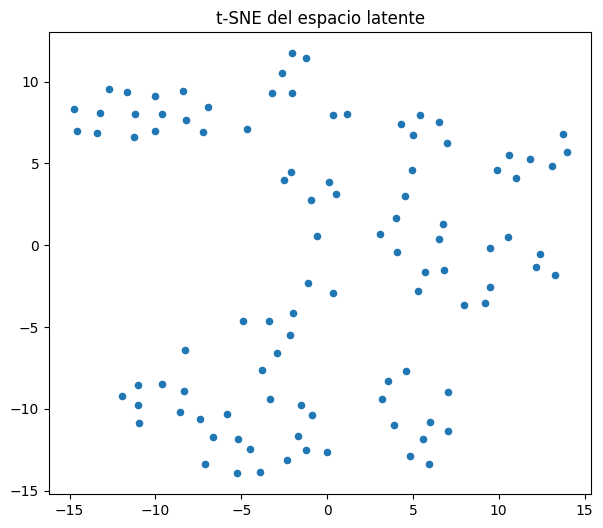

In [68]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42
)

latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(7,6))

plt.scatter(
    latent_tsne[:,0],
    latent_tsne[:,1],
    s=20,
    cmap='tab10'
)

plt.title("t-SNE del espacio latente")
plt.show()

- **Interpretación**: t-SNE revela agrupamientos locales más definidos que PCA. Esto sugiere que el encoder organiza la información utilizando relaciones no lineales complejas entre: forma del dígito, intensidad del ruido, estructura espacial de la degradación.
- En este caso, el espacio latente está compactado alrededor del origen y no colapsa en zonas concretas. Hay continuidad, la reconstrucción está siendo realizada siguiendo la estructura de dígitos similares en vecindades comunes (LOS DIGITOS DE MNIST SE DISTINGUEN PERO CONTIENEN CARACTERÍSTICAS SIMILARES: FONDO, TRAZOS, ETC. ES POR ELLO QUE LAS AGRUPACIONES DEL ESPACIO SON MUY CONTINUADAS.).

### 6.4 ¿Qué regiones afectan más a la reconstrucción? — Saliency del VAE

- La idea ahora NO es explicar una clase. Queremos explicar: qué píxeles de entrada afectan más a la reconstrucción generada.

- Saliency sobre reconstrucción.

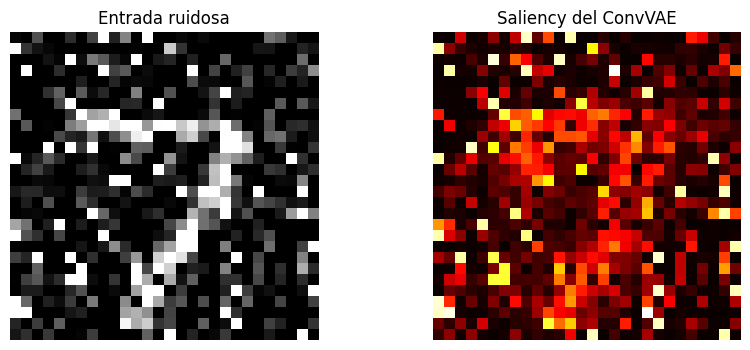

In [69]:
sample_noisy, sample_clean = test_dataset_dn[0]

input_img = sample_noisy.unsqueeze(0).to(device)
input_img.requires_grad = True

recon, _, _ = model_dn(input_img)

loss = F.mse_loss(recon, input_img)

loss.backward()

saliency = input_img.grad.abs().squeeze().cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_noisy.squeeze(), cmap='gray')
plt.title("Entrada ruidosa")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency del ConvVAE")
plt.axis('off')

plt.show()

**Interpretación**. \1- El mapa de saliencia muestra qué regiones influyen más en el proceso de reconstrucción.
- Se observa: los bordes del dígito, trazos finos, y zonas altamente degradadas: producen gradientes más intensos.
- Esto indica que el autoencoder dedica mayor capacidad de reconstrucción a regiones estructuralmente importante: EN ESTE CASO, TANTO EL DÍGITO SIETE COMO ZONAS DE ALREDEDOR (RUIDO MIXTO APLICADO) ESTÁN SIENDO CONSIDERADOS PARA LA RECONSTRUCCIÓN).

### 6.5. ¿Qué partes se pierden? — Error residual
- **Objetivo**: Visualizar explícitamente `|x - x̂|` para identificar qué regiones NO consigue reconstruir bien el VAE.

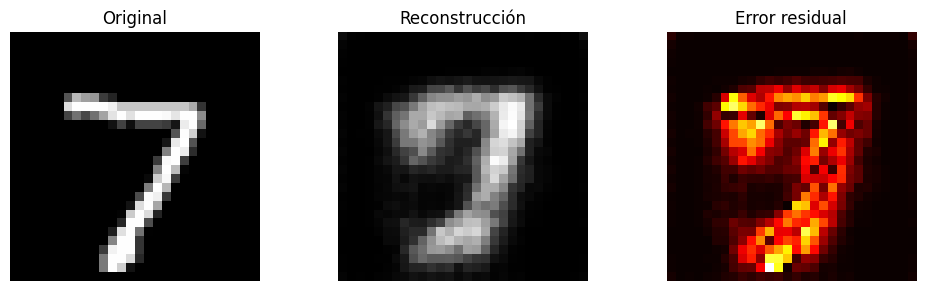

In [70]:
sample_noisy, sample_clean = test_dataset_dn[0]

model_dn.eval()

with torch.no_grad():
    recon, _, _ = model_dn(sample_noisy.unsqueeze(0).to(device))

recon = recon.squeeze().cpu().numpy()
clean = sample_clean.squeeze().numpy()

error_map = np.abs(clean - recon)

fig, axes = plt.subplots(1,3, figsize=(10,3))

axes[0].imshow(clean, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(recon, cmap='gray')
axes[1].set_title("Reconstrucción")
axes[1].axis('off')

axes[2].imshow(error_map, cmap='hot')
axes[2].set_title("Error residual")
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Interpretación**. \1- Los errores residuales se concentran principalmente en bordes finos, curvas cerradas, regiones de alto detalle y zonas afectadas por ruido impulsivo. Esto confirma que el ConvVAE aprende bien estructuras globales pero pierde precisión en detalles locales.

### 6.6. ¿Qué “imagina” el decoder? — Traversals latentes

- **Objetivo**: Modificamos dimensiones del vector latente para observar cómo cambia la reconstrucción. Esto permite interpretar qué representa cada dimensión latente.

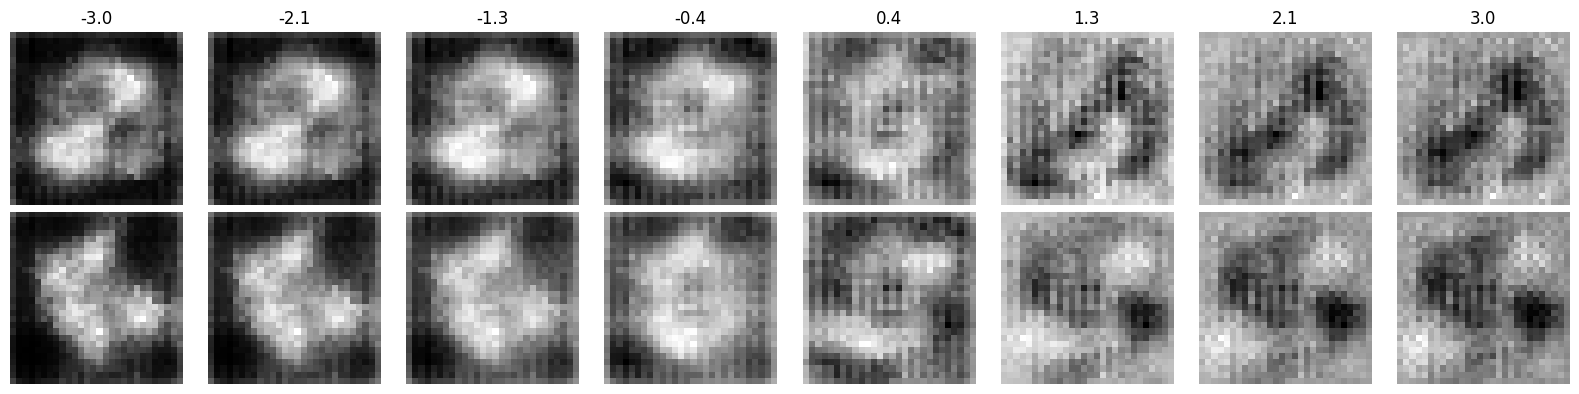

In [71]:
latent_dim = 16

z = torch.zeros((1, latent_dim)).to(device)

values = torch.linspace(-3, 3, steps=8)

fig, axes = plt.subplots(2, 8, figsize=(16,4))

for i, val in enumerate(values):

    z_mod = z.clone()

    # modificar dimensión concreta
    z_mod[0,0] = val

    with torch.no_grad():
        recon = model_dn.decode(z_mod)

    img = recon.squeeze().cpu().numpy()

    axes[0,i].imshow(img, cmap='gray')
    axes[0,i].axis('off')
    axes[0,i].set_title(f"{val:.1f}")

for i, val in enumerate(values):

    z_mod = z.clone()

    z_mod[0,1] = val

    with torch.no_grad():
        recon = model_dn.decode(z_mod)

    img = recon.squeeze().cpu().numpy()

    axes[1,i].imshow(img, cmap='gray')
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

**Interpretación**. \1- Los traversals muestran que distintas dimensiones latentes controlan grosor de trazos, intensidad del ruido, inclinación, forma global, contraste, etc. Esto confirma que el espacio latente aprendido por el ConvVAE contiene representaciones semánticas continuas.

### 6.7. Conclusión XAI del ConvVAE
- Las técnicas de explicabilidad aplicadas al ConvVAE muestran que el modelo. \1    - aprende representaciones compactas y continuas,
    - organiza imágenes similares en regiones próximas del espacio latente,
    - prioriza bordes y estructuras importantes durante la reconstrucción,
    - y genera reconstrucciones coherentes aunque suavizadas.

- Sin embargo. \1    - el espacio latente sigue siendo parcialmente abstracto,
    - algunas dimensiones son difíciles de interpretar,
    - y la reconstrucción pierde detalle fino.

**Este análisis servirá posteriormente para comparar si el modelo híbrido cuántico aprende representaciones más compactas, más separables, o potencialmente más interpretables.**